# Member 04 – MSE vs MAE (L1) Loss

## Mục tiêu

Notebook này xây dựng hai training experiments để so sánh **MSE Loss** và **MAE/L1 Loss** trong bài toán hồi quy.

Các yêu cầu chính:
- Hiểu công thức và đặc điểm của MSE và MAE.
- Xây dựng training experiment với **MSELoss**.
- Xây dựng training experiment với **L1Loss (MAE)**.
- Giữ các điều kiện khác giống nhau để so sánh công bằng.
- Theo dõi **train loss, validation loss và MAE** trong quá trình training.
- Đánh giá trên tập Test bằng **MAE, MSE và RMSE**.
- Phân tích ảnh hưởng của outlier.

## 1. Lý thuyết

### Mean Squared Error (MSE)

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

MSE bình phương sai số nên các sai số lớn bị phạt mạnh hơn.

### Mean Absolute Error (MAE)

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

MAE sử dụng trị tuyệt đối của sai số nên ít nhạy với outlier hơn MSE.

Trong PyTorch:
- MSE training loss: `nn.MSELoss()`
- MAE/L1 training loss: `nn.L1Loss()`

**Lưu ý:** `nn.MSELoss()` và `nn.L1Loss()` là loss dùng trong quá trình tối ưu model; còn MAE/MSE/RMSE ở phần Test là các metrics dùng để đánh giá model.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.14.0+cpu
Device: cpu


## 2. Tạo dataset hồi quy

Ta tạo một dataset hồi quy đơn giản:

$$
y = 3x + 2 + noise
$$

Dữ liệu được chia thành **Train / Validation / Test**.

Các experiment MSE và MAE sẽ sử dụng **đúng cùng các tập dữ liệu này**.

Train: (210, 1)
Validation: (45, 1)
Test: (45, 1)


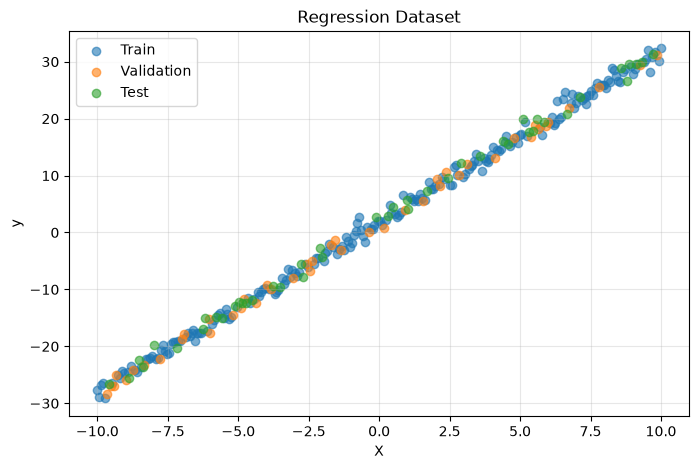

In [2]:
# Tạo dữ liệu
rng = np.random.default_rng(SEED)

X = np.linspace(-10, 10, 300).reshape(-1, 1).astype(np.float32)
noise = rng.normal(0, 1.0, size=(300, 1)).astype(np.float32)
y = (3 * X + 2 + noise).astype(np.float32)

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, label="Train", alpha=0.6)
plt.scatter(X_val, y_val, label="Validation", alpha=0.6)
plt.scatter(X_test, y_test, label="Test", alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Dataset")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Chuẩn bị Tensor và DataLoader

Để so sánh công bằng, hai experiment dùng:
- cùng dataset;
- cùng cách chia Train/Validation/Test;
- cùng batch size;
- cùng kiến trúc model;
- cùng optimizer;
- cùng learning rate;
- cùng số epochs;
- cùng random seed.

**Chỉ thay đổi loss function.**

In [3]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

BATCH_SIZE = 32
EPOCHS = 200
LEARNING_RATE = 0.01

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED)
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Batch size: 32
Epochs: 200
Learning rate: 0.01


## 4. Hàm tạo model

Hai model có **kiến trúc hoàn toàn giống nhau**.

Việc khởi tạo lại seed trước mỗi experiment giúp hai model bắt đầu từ cùng một trạng thái khởi tạo, làm cho việc so sánh MSE và MAE rõ ràng hơn.

In [4]:
def create_model():
    model = nn.Sequential(
        nn.Linear(1, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )
    return model.to(device)

## 5. Training Experiment với MSE Loss
**Kiểm soát công bằng:** `train_model()` tạo lại `DataLoader` với cùng `SEED` cho từng experiment, vì vậy MSE và MAE dùng cùng thứ tự mini-batch, cùng khởi tạo model và cùng hyperparameters. Loss function là biến duy nhất được thay đổi.


Ở experiment này, loss dùng để cập nhật trọng số là:

```python
nn.MSELoss()
```

Trong mỗi epoch, ta lưu:
- Train MSE Loss
- Validation MSE Loss
- Train MAE
- Validation MAE

In [5]:
def train_model(loss_name):
    # Reset seed để hai experiment có điều kiện khởi tạo giống nhau
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # Recreate the training loader for every experiment with the same
    # generator seed so both models receive the same mini-batch order.
    experiment_train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )

    model = create_model()

    if loss_name == "MSE":
        criterion = nn.MSELoss()
    elif loss_name == "MAE":
        criterion = nn.L1Loss()
    else:
        raise ValueError("loss_name phải là 'MSE' hoặc 'MAE'.")

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": []
    }

    for epoch in range(EPOCHS):
        # ---------- TRAIN ----------
        model.train()
        train_loss_sum = 0.0
        train_predictions = []
        train_targets = []

        for xb, yb in experiment_train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()

            predictions = model(xb)
            loss = criterion(predictions, yb)

            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * xb.size(0)
            train_predictions.append(predictions.detach().cpu().numpy())
            train_targets.append(yb.detach().cpu().numpy())

        train_loss = train_loss_sum / len(train_loader.dataset)

        train_predictions = np.concatenate(train_predictions).reshape(-1)
        train_targets = np.concatenate(train_targets).reshape(-1)

        train_mae = mean_absolute_error(
            train_targets,
            train_predictions
        )

        # ---------- VALIDATION ----------
        model.eval()
        val_loss_sum = 0.0
        val_predictions = []
        val_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)

                predictions = model(xb)
                loss = criterion(predictions, yb)

                val_loss_sum += loss.item() * xb.size(0)
                val_predictions.append(predictions.cpu().numpy())
                val_targets.append(yb.cpu().numpy())

        val_loss = val_loss_sum / len(val_loader.dataset)

        val_predictions = np.concatenate(val_predictions).reshape(-1)
        val_targets = np.concatenate(val_targets).reshape(-1)

        val_mae = mean_absolute_error(
            val_targets,
            val_predictions
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(
                f"{loss_name} | Epoch {epoch+1:3d}/{EPOCHS} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Train MAE: {train_mae:.4f} | "
                f"Val MAE: {val_mae:.4f}"
            )

    return model, history


mse_model, mse_history = train_model("MSE")

MSE | Epoch   1/200 | Train Loss: 207.7278 | Val Loss: 194.6535 | Train MAE: 12.4403 | Val MAE: 11.8373
MSE | Epoch  20/200 | Train Loss: 1.2770 | Val Loss: 1.3445 | Train MAE: 0.8486 | Val MAE: 0.9187
MSE | Epoch  40/200 | Train Loss: 0.9518 | Val Loss: 1.0224 | Train MAE: 0.7429 | Val MAE: 0.8468
MSE | Epoch  60/200 | Train Loss: 0.8778 | Val Loss: 0.9025 | Train MAE: 0.7197 | Val MAE: 0.8171
MSE | Epoch  80/200 | Train Loss: 0.8658 | Val Loss: 0.8616 | Train MAE: 0.7144 | Val MAE: 0.8083
MSE | Epoch 100/200 | Train Loss: 0.8633 | Val Loss: 0.8465 | Train MAE: 0.7127 | Val MAE: 0.8049
MSE | Epoch 120/200 | Train Loss: 0.9465 | Val Loss: 0.8257 | Train MAE: 0.7489 | Val MAE: 0.7822
MSE | Epoch 140/200 | Train Loss: 0.8642 | Val Loss: 0.8501 | Train MAE: 0.7101 | Val MAE: 0.8020
MSE | Epoch 160/200 | Train Loss: 0.8640 | Val Loss: 0.8219 | Train MAE: 0.7144 | Val MAE: 0.7934
MSE | Epoch 180/200 | Train Loss: 0.8690 | Val Loss: 0.8371 | Train MAE: 0.7151 | Val MAE: 0.8029
MSE | Epoch 20

## 6. Training Experiment với MAE / L1 Loss

Experiment này giữ nguyên tất cả điều kiện của experiment MSE.

Điểm thay đổi duy nhất:

```python
criterion = nn.L1Loss()
```

`nn.L1Loss()` chính là L1 loss, tương ứng với MAE trong bài toán hồi quy.

In [6]:
mae_model, mae_history = train_model("MAE")

MAE | Epoch   1/200 | Train Loss: 12.4332 | Val Loss: 11.8244 | Train MAE: 12.4332 | Val MAE: 11.8244
MAE | Epoch  20/200 | Train Loss: 0.7367 | Val Loss: 0.8332 | Train MAE: 0.7367 | Val MAE: 0.8332
MAE | Epoch  40/200 | Train Loss: 0.7107 | Val Loss: 0.8149 | Train MAE: 0.7107 | Val MAE: 0.8149
MAE | Epoch  60/200 | Train Loss: 0.7148 | Val Loss: 0.8100 | Train MAE: 0.7148 | Val MAE: 0.8100
MAE | Epoch  80/200 | Train Loss: 0.7122 | Val Loss: 0.7975 | Train MAE: 0.7122 | Val MAE: 0.7975
MAE | Epoch 100/200 | Train Loss: 0.7184 | Val Loss: 0.8578 | Train MAE: 0.7184 | Val MAE: 0.8578
MAE | Epoch 120/200 | Train Loss: 0.7787 | Val Loss: 0.8661 | Train MAE: 0.7787 | Val MAE: 0.8661
MAE | Epoch 140/200 | Train Loss: 0.7253 | Val Loss: 0.8235 | Train MAE: 0.7253 | Val MAE: 0.8235
MAE | Epoch 160/200 | Train Loss: 0.7125 | Val Loss: 0.8887 | Train MAE: 0.7125 | Val MAE: 0.8887
MAE | Epoch 180/200 | Train Loss: 0.7481 | Val Loss: 0.8009 | Train MAE: 0.7481 | Val MAE: 0.8009
MAE | Epoch 200/

## 7. Theo dõi Train / Validation Loss

Biểu đồ dưới đây cho thấy quá trình học của hai model.

- MSE experiment: loss được tối ưu là MSE.
- MAE experiment: loss được tối ưu là L1/MAE.

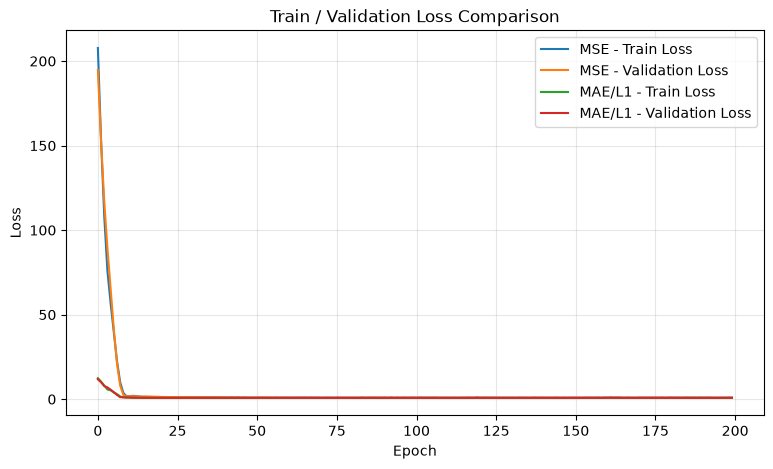

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(mse_history["train_loss"], label="MSE - Train Loss")
plt.plot(mse_history["val_loss"], label="MSE - Validation Loss")
plt.plot(mae_history["train_loss"], label="MAE/L1 - Train Loss")
plt.plot(mae_history["val_loss"], label="MAE/L1 - Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation Loss Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Theo dõi MAE trong quá trình training

MAE được tính cho cả Train và Validation ở mỗi epoch.

Điều này cho phép quan sát chất lượng dự đoán của hai model bên cạnh loss mà model đang tối ưu.

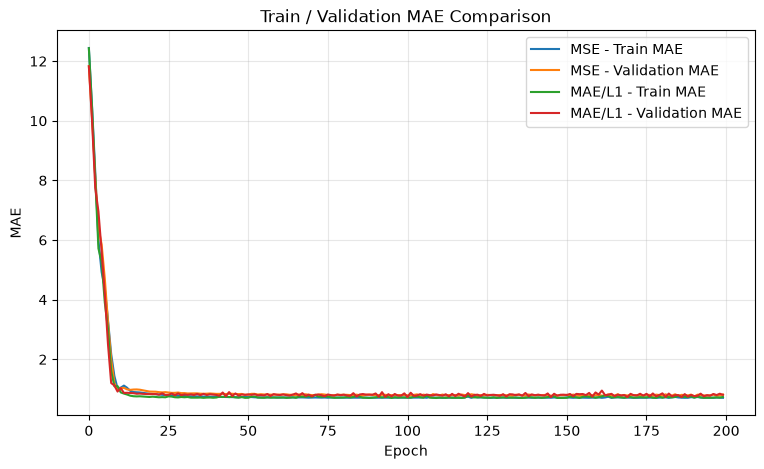

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(mse_history["train_mae"], label="MSE - Train MAE")
plt.plot(mse_history["val_mae"], label="MSE - Validation MAE")
plt.plot(mae_history["train_mae"], label="MAE/L1 - Train MAE")
plt.plot(mae_history["val_mae"], label="MAE/L1 - Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Train / Validation MAE Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Hàm đánh giá Test

Sau khi training xong, cả hai model được đánh giá trên **cùng một Test set**.

Các metrics cần tổng hợp:
- **MAE**
- **MSE**
- **RMSE**

RMSE được tính theo:

$$
RMSE = \sqrt{MSE}
$$

In [9]:
def evaluate_model(model):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)

            pred = model(xb)

            predictions.append(pred.cpu().numpy())
            targets.append(yb.numpy())

    predictions = np.concatenate(predictions).reshape(-1)
    targets = np.concatenate(targets).reshape(-1)

    mae = mean_absolute_error(targets, predictions)
    mse = mean_squared_error(targets, predictions)
    rmse = np.sqrt(mse)

    return mae, mse, rmse, predictions, targets


mse_test_mae, mse_test_mse, mse_test_rmse, mse_predictions, test_targets = evaluate_model(mse_model)
mae_test_mae, mae_test_mse, mae_test_rmse, mae_predictions, _ = evaluate_model(mae_model)

print("MSE-trained model")
print(f"Test MAE  : {mse_test_mae:.4f}")
print(f"Test MSE  : {mse_test_mse:.4f}")
print(f"Test RMSE : {mse_test_rmse:.4f}")

print("\nMAE/L1-trained model")
print(f"Test MAE  : {mae_test_mae:.4f}")
print(f"Test MSE  : {mae_test_mse:.4f}")
print(f"Test RMSE : {mae_test_rmse:.4f}")

MSE-trained model
Test MAE  : 0.7538
Test MSE  : 0.9088
Test RMSE : 0.9533

MAE/L1-trained model
Test MAE  : 0.7718
Test MSE  : 0.9407
Test RMSE : 0.9699


## 10. Tổng hợp Test MAE, MSE và RMSE

Bảng này là kết quả chính để so sánh hai training experiments.

In [10]:
test_results = pd.DataFrame({
    "Training Loss": ["MSELoss", "L1Loss (MAE)"],
    "Test MAE": [mse_test_mae, mae_test_mae],
    "Test MSE": [mse_test_mse, mae_test_mse],
    "Test RMSE": [mse_test_rmse, mae_test_rmse]
})

test_results.round(4)

,Training Loss,Test MAE,Test MSE,Test RMSE
0,MSELoss,0.7538,0.9088,0.9533
1,L1Loss (MAE),0.7718,0.9407,0.9699


## 11. So sánh dự đoán trên Test set

Biểu đồ giúp quan sát trực tiếp prediction của hai model so với giá trị thật.

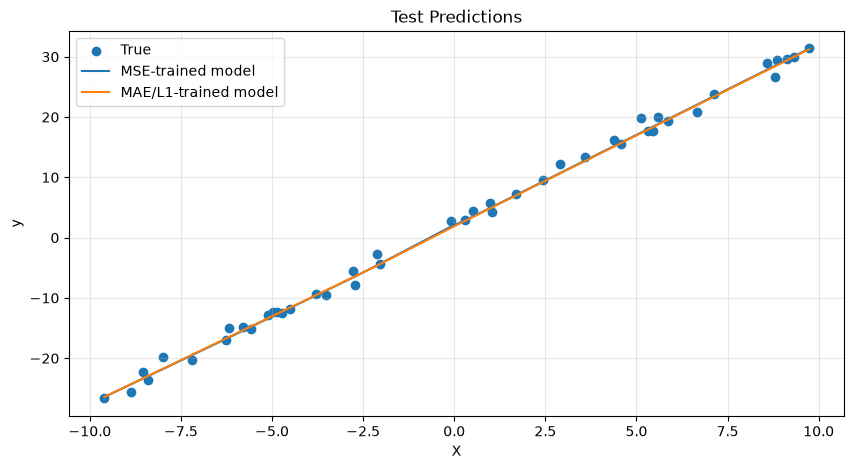

In [11]:
order = np.argsort(X_test.reshape(-1))

plt.figure(figsize=(10, 5))
plt.scatter(
    X_test.reshape(-1)[order],
    test_targets[order],
    label="True"
)
plt.plot(
    X_test.reshape(-1)[order],
    mse_predictions[order],
    label="MSE-trained model"
)
plt.plot(
    X_test.reshape(-1)[order],
    mae_predictions[order],
    label="MAE/L1-trained model"
)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Test Predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 12. Thí nghiệm ảnh hưởng của Outlier

MSE bình phương sai số nên một sai số rất lớn có thể làm MSE tăng mạnh.

Ta minh họa bằng cách thêm một prediction outlier vào cùng một tập dữ liệu.

In [12]:
y_true_outlier = np.array([10, 20, 30, 40, 50], dtype=float)

y_pred_without_outlier = np.array([11, 19, 31, 39, 51], dtype=float)
y_pred_with_outlier = np.array([11, 19, 31, 39, 80], dtype=float)

mse_normal = mean_squared_error(
    y_true_outlier,
    y_pred_without_outlier
)
mae_normal = mean_absolute_error(
    y_true_outlier,
    y_pred_without_outlier
)

mse_outlier = mean_squared_error(
    y_true_outlier,
    y_pred_with_outlier
)
mae_outlier = mean_absolute_error(
    y_true_outlier,
    y_pred_with_outlier
)

outlier_results = pd.DataFrame({
    "Case": ["Without outlier", "With outlier"],
    "MSE": [mse_normal, mse_outlier],
    "MAE": [mae_normal, mae_outlier]
})

outlier_results.round(4)

,Case,MSE,MAE
0,Without outlier,1.0,1.0
1,With outlier,180.8,6.8


In [13]:
mse_increase = mse_outlier / mse_normal
mae_increase = mae_outlier / mae_normal

print(f"MSE increase factor: {mse_increase:.2f}x")
print(f"MAE increase factor: {mae_increase:.2f}x")

MSE increase factor: 180.80x
MAE increase factor: 6.80x


## 13. Tổng kết

### Điều kiện so sánh công bằng

Hai training experiments sử dụng:
- Cùng dataset.
- Cùng Train/Validation/Test split.
- Cùng kiến trúc neural network.
- Cùng random seed.
- Cùng batch size.
- Cùng optimizer Adam.
- Cùng learning rate.
- Cùng số epochs.
- Cùng thứ tự mini-batch trong training nhờ reset DataLoader generator với cùng seed.

**Chỉ thay đổi loss function:**
- Experiment 1: `nn.MSELoss()`
- Experiment 2: `nn.L1Loss()`

### Kết quả cần báo cáo

Sau khi chạy notebook, bảng Test sẽ cung cấp:
- Test MAE
- Test MSE
- Test RMSE

Không nên kết luận rằng một loss luôn tốt hơn loss còn lại. Việc lựa chọn phụ thuộc vào mục tiêu bài toán và mức độ quan trọng của các sai số lớn/outlier.

**Điểm quan trọng:** MSE nhạy hơn với sai số lớn vì bình phương sai số, trong khi MAE/L1 ít bị ảnh hưởng bởi outlier hơn.

## 14. Kết luận cuối cùng

Notebook đã triển khai đầy đủ quy trình so sánh **MSE Loss và MAE/L1 Loss** trong một bài toán hồi quy:

1. Tạo và chia dataset.
2. Training model với MSE Loss.
3. Training model với MAE/L1 Loss.
4. Giữ các điều kiện khác giống nhau để so sánh công bằng.
5. Theo dõi Train Loss, Validation Loss và MAE.
6. Đánh giá Test bằng MAE, MSE và RMSE.
7. Phân tích ảnh hưởng của outlier.
8. Tổng hợp kết quả để phục vụ phần báo cáo Member 04.